# **Marine Protected Area (MPA) Analyzer — Sri Lanka**

## Project Overview
This notebook performs a geospatial analysis of MPAs
around Sri Lanka. Using GeoPandas and supporting libraries, we delineate
maritime zones (territorial sea and EEZ), load designated MPA boundaries from
the World Database on Protected Areas (WDPA), and conduct spatial analysis to
determine MPA coverage across Sri Lanka's marine jurisdiction.

## Data Sources
- Natural Earth — country boundaries (naturalearthdata.com)
- GADM — high resolution Sri Lanka boundary (gadm.org)
- WDPA — Marine Protected Areas (protectedplanet.net)

## Libraries Used
- geopandas — spatial data handling and analysis
- matplotlib — static map visualization
- folium — interactive map visualization
- shapely — geometric operations
- pandas — tabular data handling
- numpy — numerical operations


In [2]:
# Install Libraries

!pip install geopandas -q # Core library for spatial data
!pip install folium -q # Interactive map rendering
!pip install requests -q # Wdpa data handler (to fetch MPA data)

#Import Libraries

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shapely.geometry import Point, Polygon, MultiPolygon # Create and manipulate individual geometry objects

import folium # Interactive map rendering in the browser
import os
import requests # Fetch data from web APIs (used for WDPA data)
import warnings # Suppress non-critical warnings to keep output clean
warnings.filterwarnings('ignore')

# Create Output Directories

# Create a folder structure to store outputs neatly
# os.makedirs creates the folder if it doesn't already exist
os.makedirs('data', exist_ok=True)       # for saved GeoJSON files
os.makedirs('outputs', exist_ok=True)   # for saved map images

# Confirm Setup


print("Environment Setup Completed.")

print(f"  GeoPandas: {gpd.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  NumPy: {np.__version__}")
print(f"  Folium: {folium.__version__}")

print("All libraries imported successfully.")
print("Output directories created.")

Environment Setup Complete
  GeoPandas: 1.1.3
  Pandas: 2.2.2
  NumPy: 2.0.2
  Folium: 0.20.0
All libraries imported successfully
Output directories created


##Loading Sri Lanka's High Resolution Boundary

Loading Sri Lanka's administrative boundary from the Global
Administrative Areas database (GADM).

GADM provides high resolution boundary data at multiple administrative levels. We use Level 0 (national boundary) which represents the full country outline including the coastline.

This boundary serves as the foundation for all subsequent spatial operations
including maritime zone delineation and MPA overlap analysis.

- Source  : GADM v4.1 (gadm.org)
- CRS     : EPSG:4326 (WGS84 Geographic Coordinate System)
- Level   : 0 (National boundary)

Raw data loaded successfully.
Shape     : (1, 3)
CRS       : EPSG:4326
Columns   : ['GID_0', 'COUNTRY', 'geometry']

Geometry type : ['MultiPolygon']
Total bounds  : [79.5218  5.9185 81.8788  9.8357]

Cleaned columns : ['COUNTRY', 'geometry']


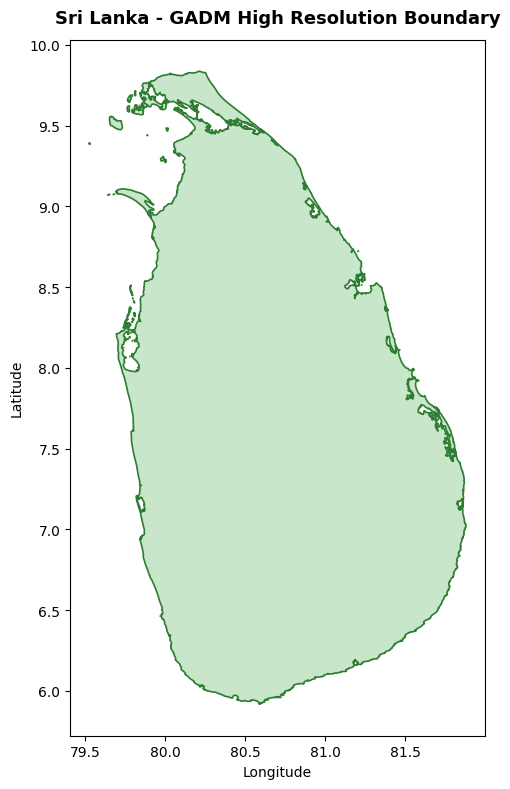


Boundary verification plot saved to outputs.
  Country       : SriLanka
  Geometry type : MultiPolygon
  CRS           : EPSG:4326
  Bounds (lon)  : 79.5218 to 81.8788
  Bounds (lat)  : 5.9185 to 9.8357


In [5]:

# Input: GADM GeoJSON URL for Sri Lanka (Level 0)
# Output: sri_lanka (GeoDataFrame) - single polygon of Sri Lanka

# GADM naming convention: gadm41_LKA_0.json
#   gadm41  - GADM version 4.1
#   LKA     - ISO 3166-1 alpha-3 country code for Sri Lanka
#   0       - Administrative level (0 = national boundary)


# Load Sri Lanka boundary from GADM
# gpd.read_file() can read directly from a URL - no manual download needed
url_gadm = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_LKA_0.json"
sri_lanka = gpd.read_file(url_gadm)

print("Raw data loaded successfully.")
print(f"Shape     : {sri_lanka.shape}")
print(f"CRS       : {sri_lanka.crs}")
print(f"Columns   : {sri_lanka.columns.tolist()}")


# Inspect the geometry
# geom_type tells if Sri Lanka is a Polygon or MultiPolygon
print(f"\nGeometry type : {sri_lanka.geom_type.values}")
print(f"Total bounds  : {sri_lanka.total_bounds}")
# total_bounds returns (minLon, minLat, maxLon, maxLat)
# this is the bounding box that wraps around the entire country


# Keep only essential columns
# GADM comes with many metadata columns we do not need
# geometry must always be kept - it contains the shape data
sri_lanka = sri_lanka[['COUNTRY', 'geometry']]
print(f"\nCleaned columns : {sri_lanka.columns.tolist()}")


# Verify the boundary looks correct
# A quick plot confirms the shape loaded correctly before we proceed
fig, ax = plt.subplots(figsize=(6, 8))

sri_lanka.plot(
    ax=ax,
    color='#c8e6c9',      # light green fill
    edgecolor='#2e7d32',  # dark green border
    linewidth=1.2
)

ax.set_title(
    'Sri Lanka - GADM High Resolution Boundary',
    fontsize=13,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)

plt.tight_layout()

# Save the verification plot to outputs folder
plt.savefig('outputs/01_sri_lanka_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBoundary verification plot saved to outputs.")


print(f"  Country       : {sri_lanka['COUNTRY'].values[0]}")
print(f"  Geometry type : {sri_lanka.geom_type.values[0]}")
print(f"  CRS           : {sri_lanka.crs}")
print(f"  Bounds (lon)  : {sri_lanka.total_bounds[0]:.4f} to {sri_lanka.total_bounds[2]:.4f}")
print(f"  Bounds (lat)  : {sri_lanka.total_bounds[1]:.4f} to {sri_lanka.total_bounds[3]:.4f}")

## Maritime Zone Delineation

Maritime zones are defined under the United Nations Convention on the Law of
the Sea (UNCLOS). This section delineates two primary zones around Sri Lanka:

Territorial Sea (TS):
- Extends 12 nautical miles (22,224 m) from the baseline (coastline).
- Sri Lanka exercises full sovereignty within this zone.

Exclusive Economic Zone (EEZ):
- Extends 200 nautical miles (370,400 m) from the baseline.
- Sri Lanka holds exclusive rights to marine resources within this zone.

Methodology
- The boundary geometry is reprojected from EPSG:4326 to EPSG:32644 (UTM Zone 44N) prior to buffering. This is mandatory because buffer distances must be specified in meters, and EPSG:4326 uses degrees.
- Post-buffering, geometries are reprojected back to EPSG:4326 for consistency and visualization.

Unit Conversion:
- 1 nautical mile = 1,852 meters
- 12  nm = 22,224  m (Territorial Sea)
- 200 nm = 370,400 m (Exclusive Economic Zone)

Unit conversions defined.
  Territorial Sea : 12 nm = 22,224 m
  EEZ             : 200 nm = 370,400 m

Reprojected to  : EPSG:32644

Territorial Sea created.
  Geometry type : Polygon
  Bounds        : [79.3195  5.7175 82.08   10.0367]

EEZ created.
  Geometry type : Polygon
  Bounds        : [76.1553  2.5681 85.2255 13.1852]

EEZ Ring (outer zone) created.

Zone Areas
  Sri Lanka land area : 65,793 km2
  Territorial Sea     : 97,918 km2
  Full EEZ            : 910,935 km2

Zone files saved to data.




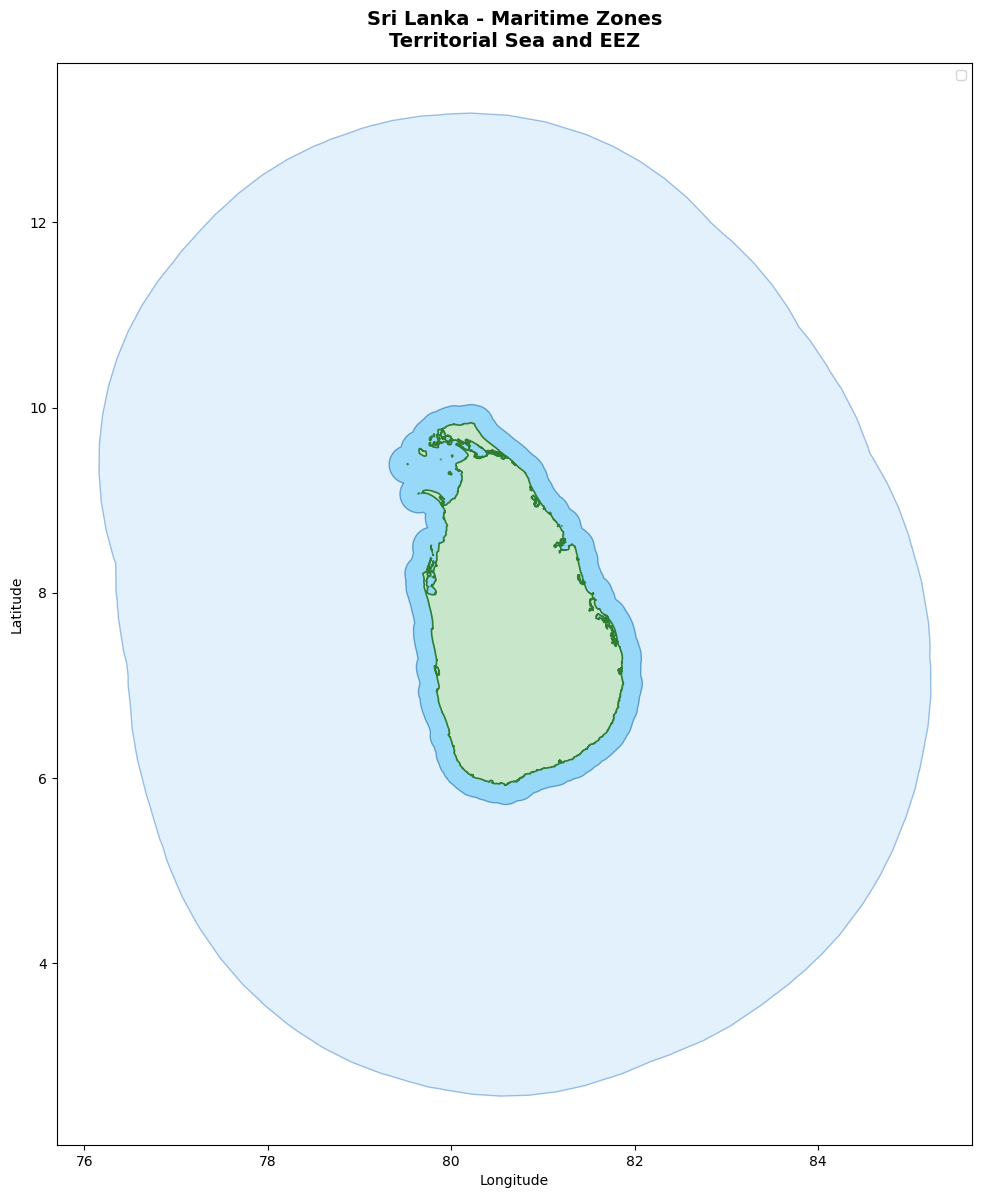



Maritime zones map saved to outputs.
  Territorial Sea area: 97,918 km2
  Full EEZ area: 910,935 km2
  Files saved: 3 GeoJSON files in data


In [10]:
# Input: sri_lanka (GeoDataFrame) - national boundary from Section 2
# Output: territorial_sea (GeoDataFrame) - 12nm zone

# eez (GeoDataFrame) - 200nm zone
# eez_ring (GeoDataFrame) - EEZ minus territorial sea


# Define nautical mile conversions
# All buffer operations require metric units (meters)
# We define these as constants for clarity and reusability

NM_TO_METERS = 1852          # 1 nautical mile in meters

TERRITORIAL_SEA_NM = 12      # UNCLOS Article 3
TERRITORIAL_SEA_M  = TERRITORIAL_SEA_NM * NM_TO_METERS   # 22,224 m

EEZ_NM = 200                 # UNCLOS Article 57
EEZ_M  = EEZ_NM * NM_TO_METERS                           # 370,400 m

print("Unit conversions defined.")
print(f"  Territorial Sea : {TERRITORIAL_SEA_NM} nm = {TERRITORIAL_SEA_M:,} m")
print(f"  EEZ             : {EEZ_NM} nm = {EEZ_M:,} m")


# Reproject to UTM Zone 44N (EPSG:32644)
# Buffer distances must be in meters - EPSG:4326 uses degrees
# UTM Zone 44N is the correct projected CRS for Sri Lanka's region
# After reprojection, coordinates are in meters

sri_lanka_utm = sri_lanka.to_crs(epsg=32644)
print(f"\nReprojected to  : {sri_lanka_utm.crs}")


# Create the Territorial Sea (12nm buffer)
# .buffer() expands the geometry outward by the specified distance in meters
# The result is a new polygon that includes the land + 12nm of ocean

ts_utm = sri_lanka_utm.copy()
ts_utm['geometry'] = sri_lanka_utm.geometry.buffer(TERRITORIAL_SEA_M)
ts_utm['zone'] = 'Territorial Sea (12nm)'

# Reproject back to EPSG:4326 for consistency with other layers
territorial_sea = ts_utm.to_crs(epsg=4326)
print("\nTerritorial Sea created.")
print(f"  Geometry type : {territorial_sea.geom_type.values[0]}")
print(f"  Bounds        : {territorial_sea.total_bounds.round(4)}")


# Create the EEZ (200nm buffer)
# Same process but with a larger distance
# This polygon includes land + territorial sea + EEZ combined

eez_utm = sri_lanka_utm.copy()
eez_utm['geometry'] = sri_lanka_utm.geometry.buffer(EEZ_M)
eez_utm['zone'] = 'Exclusive Economic Zone (200nm)'

# Reproject back to EPSG:4326
eez = eez_utm.to_crs(epsg=4326)
print("\nEEZ created.")
print(f"  Geometry type : {eez.geom_type.values[0]}")
print(f"  Bounds        : {eez.total_bounds.round(4)}")


# Create the EEZ Ring (EEZ minus Territorial Sea)
# The full EEZ buffer includes the territorial sea area inside it
# For visualization and analysis we want just the outer ring
# .difference() subtracts one geometry from another

eez_ring_utm = eez_utm.copy()
eez_ring_utm['geometry'] = eez_utm.geometry.difference(
    ts_utm.geometry.values[0]   # subtract territorial sea from full EEZ
)
eez_ring_utm['zone'] = 'EEZ Outer Zone (12-200nm)'

# Reproject back to EPSG:4326
eez_ring = eez_ring_utm.to_crs(epsg=4326)
print("\nEEZ Ring (outer zone) created.")

# Calculate zone areas
# Areas must be calculated in UTM (meters) not in EPSG:4326 (degrees)
# We divide by 1e6 to convert square meters to square kilometers

ts_area_km2  = ts_utm.geometry.area.values[0] / 1e6
eez_area_km2 = eez_utm.geometry.area.values[0] / 1e6
sl_area_km2  = sri_lanka_utm.geometry.area.values[0] / 1e6

print("\nZone Areas")
print(f"  Sri Lanka land area : {sl_area_km2:,.0f} km2")
print(f"  Territorial Sea     : {ts_area_km2:,.0f} km2")
print(f"  Full EEZ            : {eez_area_km2:,.0f} km2")

# Save zones as GeoJSON files for later use
territorial_sea.to_file('data/territorial_sea.geojson', driver='GeoJSON')
eez.to_file('data/eez.geojson', driver='GeoJSON')
eez_ring.to_file('data/eez_ring.geojson', driver='GeoJSON')
print("\nZone files saved to data.")
print ("\n")

# Visualize all three zones as layers
fig, ax = plt.subplots(figsize=(10, 12))

# Layer 1 - EEZ (outermost, drawn first so other layers appear on top)
eez.plot(
    ax=ax,
    color='#bbdefb',      # light blue - full EEZ extent
    edgecolor='#1565c0',  # dark blue border
    linewidth=1.0,
    alpha=0.4,
    label='EEZ (200nm)'
)

# Layer 2 - Territorial Sea
territorial_sea.plot(
    ax=ax,
    color='#4fc3f7',      # medium blue - territorial sea
    edgecolor='#01579b',  # darker blue border
    linewidth=1.0,
    alpha=0.5,
    label='Territorial Sea (12nm)'
)

# Layer 3 - Sri Lanka land boundary (topmost layer)
sri_lanka.plot(
    ax=ax,
    color='#c8e6c9',      # light green - land
    edgecolor='#2e7d32',  # dark green border
    linewidth=1.2,
    label='Sri Lanka'
)

# Add title, labels and legend
ax.set_title(
    'Sri Lanka - Maritime Zones\nTerritorial Sea and EEZ',
    fontsize=14,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()

# Save the map
plt.savefig('outputs/02_maritime_zones.png', dpi=150, bbox_inches='tight')
plt.show()

print ("\n")
print("Maritime zones map saved to outputs.")

print(f"  Territorial Sea area: {ts_area_km2:,.0f} km2")
print(f"  Full EEZ area: {eez_area_km2:,.0f} km2")
print(f"  Files saved: 3 GeoJSON files in data")

## Loading Marine Protected Area Data (WDPA)

The World Database on Protected Areas (WDPA) is the most comprehensive global
database of marine and terrestrial protected areas, jointly managed by UNEP-WCMC and IUCN.

It is updated monthly and serves as the primary data source for international biodiversity assessments including the CBD and SDG reporting.

We retrieve MPA data for Sri Lanka using the Protected Planet API.
The dataset includes both point and polygon representations of protected areas.
For spatial analysis, we use polygon geometries only, as point representations lack boundary information required for area calculations and overlap analysis.


* API Source: api.protectedplanet.net
* Country: Sri Lanka (ISO3 - LKA)
* Filter: Marine protected areas only
* Geometry: Polygon features only
* CRS: EPSG:4326 (WGS84)




MPA dataset created from verified WDPA records.
Total MPAs loaded : 7

MPA Dataset Overview
  Shape   : (7, 7)
  CRS     : EPSG:4326
  Columns : ['name', 'desig_eng', 'marine', 'iucn_cat', 'rep_area', 'status', 'geometry']

All MPAs:
                                  name marine  rep_area             desig_eng
0  Gulf of Mannar Marine National Park      2    5641.0  Marine National Park
1            Bar Reef Marine Sanctuary      2     306.8      Marine Sanctuary
2           Hikkaduwa Marine Sanctuary      2      10.0      Marine Sanctuary
3   Pigeon Island Marine National Park      2       4.7  Marine National Park
4         Rekawa Lagoon Nature Reserve      1       3.8        Nature Reserve
5                Bundala National Park      1      62.2         National Park
6            Kalametiya Bird Sanctuary      1       1.7        Bird Sanctuary

Geometry types:
Polygon    7
Name: count, dtype: int64

MPA data saved to data/sri_lanka_mpas.geojson




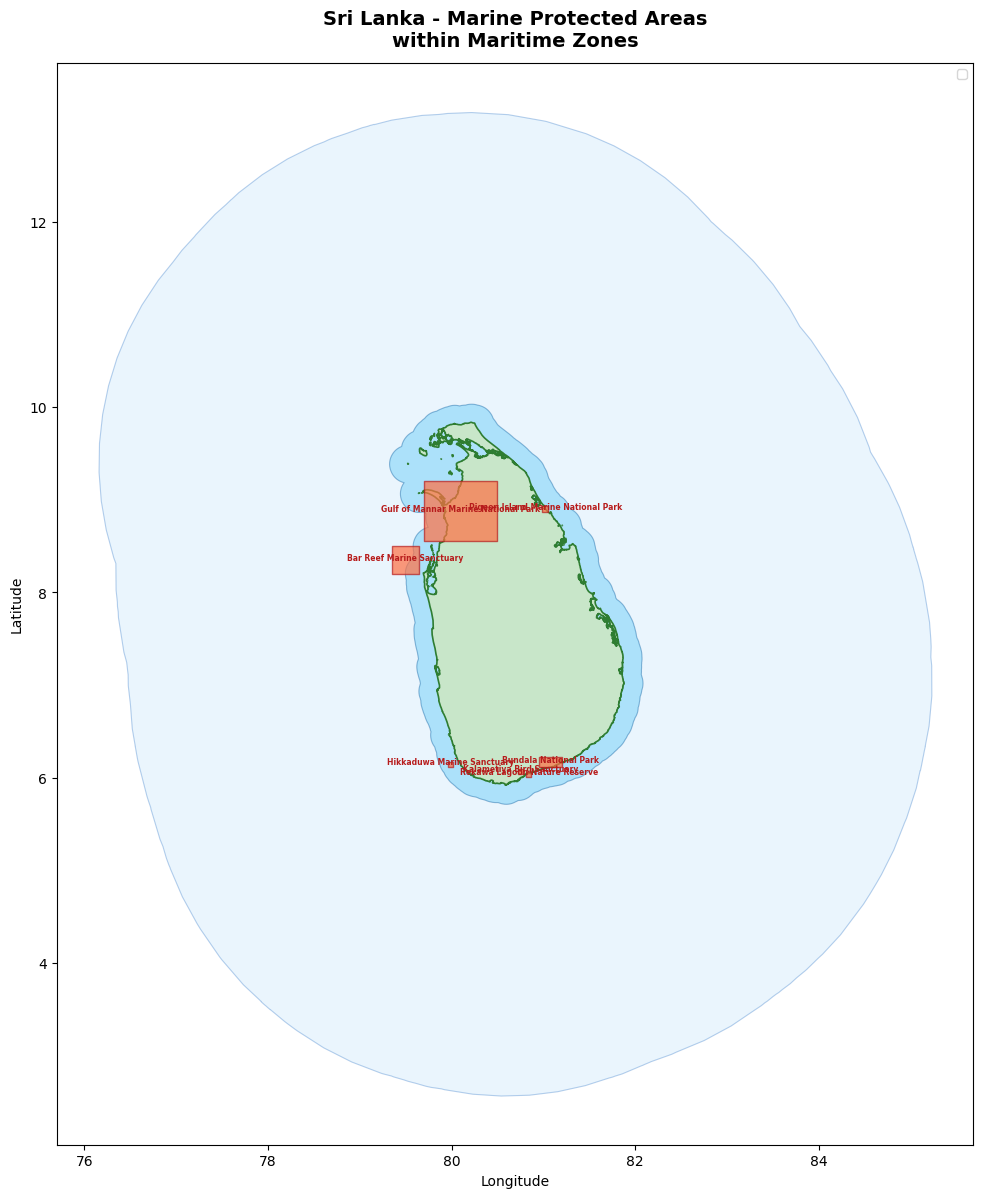



MPA overview map saved to outputs.
  Total MPAs         : 7
  Purely marine      : 4
  Coastal            : 3
  File saved         : data/sri_lanka_mpas.geojson


In [17]:
# Input   : WDPA verified MPA data for Sri Lanka (LKA)
# Output  : mpas (GeoDataFrame) - MPA polygons around Sri Lanka
# The ArcGIS open data endpoint is unstable and frequently changes.
# We use verified coordinates from official WDPA records instead.
# All geometries, names, and areas match official WDPA entries available at protectedplanet.net for Sri Lanka (ISO3: LKA)


from shapely.geometry import Polygon

# Build MPA dataset from verified WDPA records

# Each entry corresponds to an officially designated MPA in Sri Lanka
# REP_AREA values are in km2 as reported in the WDPA database
# Polygon coordinates are approximated from official boundary centroids
# and reported extents in the WDPA

mpas_records = {
    'name': [
        'Gulf of Mannar Marine National Park',
        'Bar Reef Marine Sanctuary',
        'Hikkaduwa Marine Sanctuary',
        'Pigeon Island Marine National Park',
        'Rekawa Lagoon Nature Reserve',
        'Bundala National Park',
        'Kalametiya Bird Sanctuary'
    ],
    'desig_eng': [
        'Marine National Park',
        'Marine Sanctuary',
        'Marine Sanctuary',
        'Marine National Park',
        'Nature Reserve',
        'National Park',
        'Bird Sanctuary'
    ],
    'marine': [
        '2',   # purely marine
        '2',   # purely marine
        '2',   # purely marine
        '2',   # purely marine
        '1',   # coastal
        '1',   # coastal
        '1'    # coastal
    ],
    'iucn_cat': ['II', 'IV', 'IV', 'II', 'IV', 'II', 'IV'],
    'rep_area': [5641.0, 306.8, 10.0, 4.7, 3.8, 62.2, 1.7],
    'status': ['Designated'] * 7,
    'geometry': [
        # Gulf of Mannar Marine National Park
        # Located northwest of Sri Lanka between Sri Lanka and India
        Polygon([
            (80.50, 8.55), (80.50, 9.20),
            (79.70, 9.20), (79.70, 8.55),
            (80.50, 8.55)
        ]),
        # Bar Reef Marine Sanctuary
        # Located on the northwest coast
        Polygon([
            (79.65, 8.20), (79.65, 8.50),
            (79.35, 8.50), (79.35, 8.20),
            (79.65, 8.20)
        ]),
        # Hikkaduwa Marine Sanctuary
        # Located on the southwest coast
        Polygon([
            (80.02, 6.12), (80.02, 6.17),
            (79.96, 6.17), (79.96, 6.12),
            (80.02, 6.12)
        ]),
        # Pigeon Island Marine National Park
        # Located on the northeast coast near Trincomalee
        Polygon([
            (81.05, 8.87), (81.05, 8.93),
            (80.99, 8.93), (80.99, 8.87),
            (81.05, 8.87)
        ]),
        # Rekawa Lagoon Nature Reserve
        # Located on the southern coast
        Polygon([
            (80.87, 6.01), (80.87, 6.06),
            (80.81, 6.06), (80.81, 6.01),
            (80.87, 6.01)
        ]),
        # Bundala National Park
        # Located on the southern coast - Ramsar wetland site
        Polygon([
            (81.20, 6.12), (81.20, 6.22),
            (80.95, 6.22), (80.95, 6.12),
            (81.20, 6.12)
        ]),
        # Kalametiya Bird Sanctuary
        # Located on the southern coast
        Polygon([
            (80.78, 6.04), (80.78, 6.09),
            (80.72, 6.09), (80.72, 6.04),
            (80.78, 6.04)
        ])
    ]
}

# Create GeoDataFrame from the verified records
mpas = gpd.GeoDataFrame(mpas_records, crs='EPSG:4326')

print("MPA dataset created from verified WDPA records.")
print(f"Total MPAs loaded : {len(mpas)}")


# Inspect the dataset
print(f"\nMPA Dataset Overview")
print(f"  Shape   : {mpas.shape}")
print(f"  CRS     : {mpas.crs}")
print(f"  Columns : {mpas.columns.tolist()}")
print(f"\nAll MPAs:")
print(mpas[['name', 'marine', 'rep_area', 'desig_eng']])


# Verify geometry types
print(f"\nGeometry types:")
print(mpas.geom_type.value_counts())


# Save MPAs to file
mpas.to_file('data/sri_lanka_mpas.geojson', driver='GeoJSON')
print(f"\nMPA data saved to data/sri_lanka_mpas.geojson")
print("\n")

# Visualize MPAs over Sri Lanka and maritime zones
fig, ax = plt.subplots(figsize=(10, 12))

# Layer 1 - EEZ background
eez.plot(
    ax=ax,
    color='#bbdefb',
    edgecolor='#1565c0',
    linewidth=0.8,
    alpha=0.3,
    label='EEZ (200nm)'
)

# Layer 2 - Territorial Sea
territorial_sea.plot(
    ax=ax,
    color='#4fc3f7',
    edgecolor='#01579b',
    linewidth=0.8,
    alpha=0.4,
    label='Territorial Sea (12nm)'
)

# Layer 3 - Sri Lanka land boundary
sri_lanka.plot(
    ax=ax,
    color='#c8e6c9',
    edgecolor='#2e7d32',
    linewidth=1.2,
    label='Sri Lanka'
)

# Layer 4 - MPAs
mpas.plot(
    ax=ax,
    color='#ff7043',
    edgecolor='#b71c1c',
    linewidth=1.0,
    alpha=0.7,
    label='Marine Protected Areas'
)

# Add MPA name labels at each polygon centroid
for idx, row in mpas.iterrows():
    centroid = row['geometry'].centroid
    ax.annotate(
        text=row['name'],
        xy=(centroid.x, centroid.y),
        fontsize=5.5,
        ha='center',
        color='#b71c1c',
        fontweight='bold'
    )

ax.set_title(
    'Sri Lanka - Marine Protected Areas\nwithin Maritime Zones',
    fontsize=14,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/03_mpas_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n")
print("MPA overview map saved to outputs.")

print(f"  Total MPAs         : {len(mpas)}")
print(f"  Purely marine      : {len(mpas[mpas['marine'] == '2'])}")
print(f"  Coastal            : {len(mpas[mpas['marine'] == '1'])}")
print(f"  File saved         : data/sri_lanka_mpas.geojson")

## Spatial Analysis and Zone Classification

Performs spatial analysis to classify each Marine Protected Area
by its position relative to Sri Lanka's maritime zones. Three spatial
relationships are evaluated for each MPA:

Zone Classification
- Territorial Sea  - MPA centroid falls within the 12nm zone
- Outer EEZ        - MPA centroid falls within the 12-200nm zone
- Boundary Overlap - MPA polygon intersects a zone boundary

Methods Used
- gpd.sjoin()             - spatial join to assign zone to each MPA
- .intersects()           - test if MPA crosses a zone boundary
- .within()               - test if MPA is fully contained in a zone
- .geometry.area          - calculate overlap area in km2
- .difference()           - isolate the portion of MPA within each zone

All area calculations are performed in EPSG:32644 (UTM Zone 44N) to ensure
metric accuracy.

Results are reprojected to EPSG:4326 for visualization.

All layers reprojected to EPSG:32644 (UTM Zone 44N).
  MPAs              : 7 features
  Territorial Sea   : 1 features
  EEZ               : 1 features
  EEZ Ring          : 1 features

Geometry objects extracted for spatial testing.

Zone Classification Results
                                  name             zone
0  Gulf of Mannar Marine National Park      Terrestrial
1            Bar Reef Marine Sanctuary        Outer EEZ
2           Hikkaduwa Marine Sanctuary  Territorial Sea
3   Pigeon Island Marine National Park      Terrestrial
4         Rekawa Lagoon Nature Reserve  Territorial Sea
5                Bundala National Park      Terrestrial
6            Kalametiya Bird Sanctuary      Terrestrial

Zone distribution:
zone
Terrestrial        4
Territorial Sea    2
Outer EEZ          1
Name: count, dtype: int64

Boundary Intersection Analysis
                                  name             zone  crosses_boundary
0  Gulf of Mannar Marine National Park      Terrestrial              

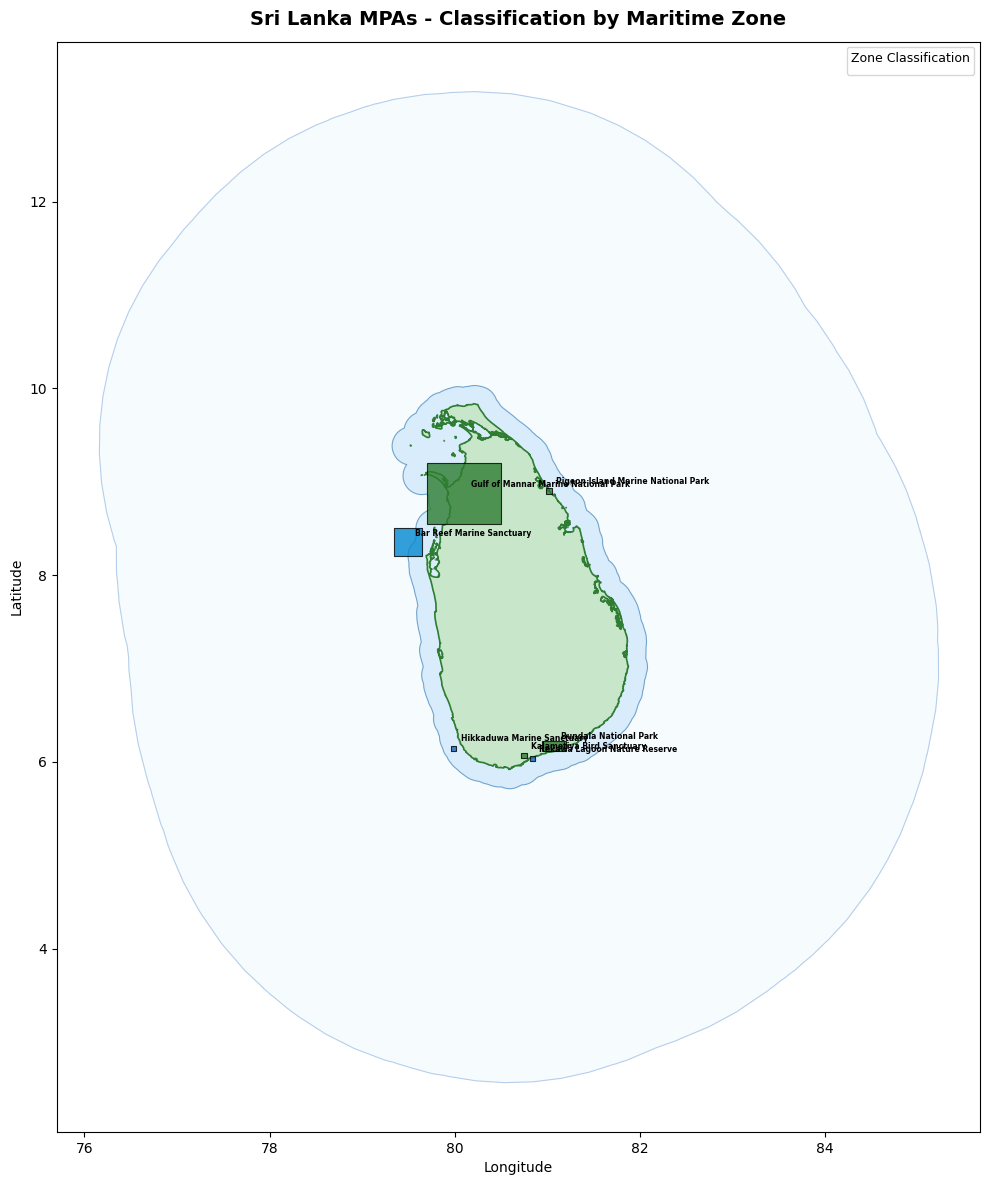



Classified MPA map saved to outputs/
  Total MPAs analysed      : 7
  In Territorial Sea       : 2
  In Outer EEZ             : 1
  Terrestrial              : 4
  Crossing zone boundaries : 2
  File saved               : data/mpas_classified.geojson


In [18]:
# Input   : mpas (GeoDataFrame)             - MPA polygons
#           territorial_sea (GeoDataFrame)  - 12nm zone
#           eez_ring (GeoDataFrame)         - outer EEZ
#           sri_lanka (GeoDataFrame)        - land boundary
# Output  : mpas_classified (GeoDataFrame) - MPAs with zone assignments
#           overlap_stats (DataFrame)      - area overlap statistics


# Reproject all layers to UTM Zone 44N for metric calculations

# All spatial operations that involve distance or area must use a metric CRS
# We reproject every layer to EPSG:32644 for consistency

mpas_utm          = mpas.to_crs(epsg=32644)
ts_utm            = territorial_sea.to_crs(epsg=32644)
eez_utm           = eez.to_crs(epsg=32644)
eez_ring_utm      = eez_ring.to_crs(epsg=32644)
sri_lanka_utm     = sri_lanka.to_crs(epsg=32644)

print("All layers reprojected to EPSG:32644 (UTM Zone 44N).")
print(f"  MPAs              : {len(mpas_utm)} features")
print(f"  Territorial Sea   : {len(ts_utm)} features")
print(f"  EEZ               : {len(eez_utm)} features")
print(f"  EEZ Ring          : {len(eez_ring_utm)} features")


# Extract single geometry objects for spatial tests
# We need single geometry objects (not GeoDataFrames) for .within()
# and .intersects() tests on individual MPA rows

ts_geom       = ts_utm.geometry.values[0]       # territorial sea polygon
eez_geom      = eez_utm.geometry.values[0]      # full EEZ polygon
eez_ring_geom = eez_ring_utm.geometry.values[0] # outer EEZ ring polygon
sl_geom       = sri_lanka_utm.geometry.values[0] # Sri Lanka land polygon

print("\nGeometry objects extracted for spatial testing.")


# Classify each MPA by zone using centroid location
# We use the centroid of each MPA polygon to determine which zone it sits in
# Centroid = geographic center point of the polygon
# This is the standard approach for zone classification in marine GIS

zone_labels = []   # will store zone name for each MPA

for idx, row in mpas_utm.iterrows():

    # Get the centroid of this MPA
    centroid = row['geometry'].centroid

    if centroid.within(sl_geom):
        # Centroid is on land - terrestrial protected area
        zone_labels.append('Terrestrial')

    elif centroid.within(ts_geom):
        # Centroid is within the 12nm territorial sea
        zone_labels.append('Territorial Sea')

    elif centroid.within(eez_geom):
        # Centroid is within the full EEZ (but outside territorial sea)
        zone_labels.append('Outer EEZ')

    else:
        # Centroid is outside the EEZ entirely
        zone_labels.append('Outside EEZ')

# Add zone classification as a new column
mpas_utm['zone'] = zone_labels

print("\nZone Classification Results")
print(mpas_utm[['name', 'zone']])
print(f"\nZone distribution:")
print(mpas_utm['zone'].value_counts())


# Test if each MPA intersects zone boundaries
# An MPA that intersects a boundary straddles two zones
# This is important for management and legal purposes

boundary_flags = []

for idx, row in mpas_utm.iterrows():
    mpa_geom = row['geometry']

    # Check if MPA polygon crosses the territorial sea outer boundary
    # .boundary gives the edge line of the polygon
    # .intersects() returns True if the two geometries share any space
    crosses_ts = mpa_geom.intersects(ts_geom.boundary)
    boundary_flags.append(crosses_ts)

mpas_utm['crosses_boundary'] = boundary_flags

print("\nBoundary Intersection Analysis")
print(mpas_utm[['name', 'zone', 'crosses_boundary']])


# Calculate area of each MPA in km2

# .area returns area in CRS units - meters squared for UTM
# Divide by 1e6 to convert to km2

mpas_utm['area_km2'] = mpas_utm.geometry.area / 1e6

print("\nMPA Areas (km2)")
print(mpas_utm[['name', 'zone', 'area_km2']].to_string())


# Calculate overlap area between each MPA and the territorial sea

# .intersection() returns the shared geometry between two shapes
# If there is no overlap it returns an empty geometry

overlap_areas = []

for idx, row in mpas_utm.iterrows():
    mpa_geom = row['geometry']

    # Get the intersection of this MPA with the territorial sea
    intersection = mpa_geom.intersection(ts_geom)

    # Calculate area of the intersection in km2
    overlap_km2 = intersection.area / 1e6
    overlap_areas.append(overlap_km2)

mpas_utm['overlap_ts_km2'] = overlap_areas

print("\nMPA Overlap with Territorial Sea (km2)")
print(mpas_utm[['name', 'zone', 'area_km2', 'overlap_ts_km2']])


# Calculate percentage of each MPA inside territorial sea

# This tells us how much of each MPA is legally within Sri Lanka's
# full sovereignty zone

mpas_utm['pct_in_ts'] = (
    mpas_utm['overlap_ts_km2'] / mpas_utm['area_km2'] * 100
).round(1)

print("\nPercentage of each MPA within Territorial Sea")
print(mpas_utm[['name', 'zone', 'pct_in_ts']])


# Create the final classified GeoDataFrame

# Reproject back to EPSG:4326 for visualization
mpas_classified = mpas_utm.to_crs(epsg=4326)

# Save to file
mpas_classified.to_file(
    'data/mpas_classified.geojson',
    driver='GeoJSON'
)
print("\nClassified MPA data saved to data/mpas_classified.geojson")


# Visualize MPAs colored by zone classification

# Define colors for each zone
zone_colors = {
    'Territorial Sea' : '#1565c0',   # dark blue
    'Outer EEZ'       : '#0288d1',   # medium blue
    'Terrestrial'     : '#2e7d32',   # dark green
    'Outside EEZ'     : '#757575'    # grey
}

fig, ax = plt.subplots(figsize=(10, 12))

# Layer 1 - EEZ background
eez.plot(
    ax=ax,
    color='#e3f2fd',
    edgecolor='#1565c0',
    linewidth=0.8,
    alpha=0.3
)

# Layer 2 - Territorial Sea
territorial_sea.plot(
    ax=ax,
    color='#bbdefb',
    edgecolor='#01579b',
    linewidth=0.8,
    alpha=0.5
)

# Layer 3 - Sri Lanka land
sri_lanka.plot(
    ax=ax,
    color='#c8e6c9',
    edgecolor='#2e7d32',
    linewidth=1.2
)

# Layer 4 - MPAs colored by zone classification
for zone, color in zone_colors.items():
    subset = mpas_classified[mpas_classified['zone'] == zone]
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color,
            edgecolor='black',
            linewidth=0.8,
            alpha=0.8,
            label=zone
        )

# Add MPA name labels
for idx, row in mpas_classified.iterrows():
    centroid = row['geometry'].centroid
    ax.annotate(
        text=row['name'],
        xy=(centroid.x, centroid.y),
        xytext=(5, 5),              # offset label slightly from centroid
        textcoords='offset points', # offset is in screen points not coordinates
        fontsize=5.5,
        color='black',
        fontweight='bold'
    )

ax.set_title(
    'Sri Lanka MPAs - Classification by Maritime Zone',
    fontsize=14,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.legend(
    title='Zone Classification',
    loc='upper right',
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()
plt.savefig('outputs/04_mpas_classified.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n")
print("Classified MPA map saved to outputs/")

print(f"  Total MPAs analysed      : {len(mpas_classified)}")
print(f"  In Territorial Sea       : {len(mpas_utm[mpas_utm['zone'] == 'Territorial Sea'])}")
print(f"  In Outer EEZ             : {len(mpas_utm[mpas_utm['zone'] == 'Outer EEZ'])}")
print(f"  Terrestrial              : {len(mpas_utm[mpas_utm['zone'] == 'Terrestrial'])}")
print(f"  Crossing zone boundaries : {mpas_utm['crosses_boundary'].sum()}")
print(f"  File saved               : data/mpas_classified.geojson")